# 10. Activation 분석

이번 노트북은 Activation 단계만 다룹니다.

## 분석 질문
- 어떤 세그먼트에서 신규가입 증가가 정기권 이용으로 더 잘 이어지는가?
- 가입은 했는데, 실제로 타고 있나?

## 분석 내용
1. 신규가입자 1인당 정기권 이용건수
2. 신규가입 이후 같은 달 정기권 이용 비중
3. 세그먼트별 첫 이용 강도 비교

공개데이터에는 개인 식별자가 없기 때문에 이 분석은 개인 단위 전환율이 아니라 `월 × 성별 × 연령대` 수준의 Activation proxy 분석입니다.

In [17]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Malgun Gothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 1. 경로 설정 및 DB 연결

In [18]:
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = DATA_DIR / "seoul_bike.db"
SQL_DIR = PROJECT_ROOT / "sql"
REPORT_DIR = PROJECT_ROOT / "reports"
IMAGE_DIR = PROJECT_ROOT / "images/activation"

if not DB_PATH.exists() and Path("/mnt/data/seoul_bike.db").exists():
    PROJECT_ROOT = Path("/mnt/data")
    DB_PATH = PROJECT_ROOT / "seoul_bike.db"
    SQL_DIR = PROJECT_ROOT
    REPORT_DIR = PROJECT_ROOT
    IMAGE_DIR = PROJECT_ROOT / "images/activation"

SQL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB_PATH)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DB_PATH:", DB_PATH)

PROJECT_ROOT: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis
DB_PATH: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\data\seoul_bike.db


In [19]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
if "mart_growth_month" not in set(tables["name"]):
    raise ValueError("mart_growth_month 테이블이 없습니다. 04_make_mart_tables 실행 후 다시 실행하세요.")
print("mart_growth_month 확인 완료")

mart_growth_month 확인 완료


## 2. 분석 SQL 저장

In [20]:
ACTIVATION_SQL = r"""-- 07_activation_analysis_queries.sql
-- Activation 분석 SQL
-- 사용 테이블: mart_growth_month

-- 1. 월별 Activation 흐름: 기타 포함, unknown 제외
WITH monthly AS (
    SELECT
        month_ym,
        month_date,
        SUM(signup_cnt) AS signup_cnt,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM mart_growth_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym, month_date
)
SELECT
    month_ym,
    month_date,
    signup_cnt,
    sub_ride_cnt,
    total_ride_cnt,
    ROUND(CASE WHEN signup_cnt > 0 THEN 1.0 * sub_ride_cnt / signup_cnt ELSE NULL END, 4) AS sub_rides_per_signup,
    ROUND(CASE WHEN total_ride_cnt > 0 THEN 1.0 * sub_ride_cnt / total_ride_cnt ELSE NULL END, 4) AS same_month_subscription_share
FROM monthly
ORDER BY month_ym;

-- 2. 세그먼트별 Activation 강도: 기타 제외, unknown 제외
WITH segment AS (
    SELECT
        gender,
        age_band,
        SUM(signup_cnt) AS signup_cnt,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM mart_growth_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY gender, age_band
),
total AS (
    SELECT
        SUM(signup_cnt) AS total_signup_cnt,
        SUM(sub_ride_cnt) AS total_sub_ride_cnt
    FROM segment
)
SELECT
    RANK() OVER (ORDER BY 1.0 * s.sub_ride_cnt / NULLIF(s.signup_cnt, 0) DESC) AS activation_rank,
    s.gender,
    s.age_band,
    s.signup_cnt,
    s.sub_ride_cnt,
    s.total_ride_cnt,
    ROUND(CASE WHEN s.signup_cnt > 0 THEN 1.0 * s.sub_ride_cnt / s.signup_cnt ELSE NULL END, 4) AS sub_rides_per_signup,
    ROUND(CASE WHEN s.total_ride_cnt > 0 THEN 1.0 * s.sub_ride_cnt / s.total_ride_cnt ELSE NULL END, 4) AS same_month_subscription_share,
    ROUND(1.0 * s.signup_cnt / t.total_signup_cnt, 4) AS signup_share,
    ROUND(1.0 * s.sub_ride_cnt / t.total_sub_ride_cnt, 4) AS sub_ride_share,
    ROUND(1.0 * s.sub_ride_cnt / t.total_sub_ride_cnt - 1.0 * s.signup_cnt / t.total_signup_cnt, 4) AS sub_vs_signup_share_gap
FROM segment s
CROSS JOIN total t
ORDER BY sub_rides_per_signup DESC;

-- 3. 세그먼트 유형 분류
WITH segment AS (
    SELECT
        gender,
        age_band,
        SUM(signup_cnt) AS signup_cnt,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt,
        CASE WHEN SUM(signup_cnt) > 0 THEN 1.0 * SUM(sub_ride_cnt) / SUM(signup_cnt) ELSE NULL END AS sub_rides_per_signup,
        CASE WHEN SUM(total_ride_cnt) > 0 THEN 1.0 * SUM(sub_ride_cnt) / SUM(total_ride_cnt) ELSE NULL END AS same_month_subscription_share
    FROM mart_growth_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY gender, age_band
),
ranked AS (
    SELECT
        *,
        NTILE(4) OVER (ORDER BY signup_cnt) AS signup_quartile,
        NTILE(4) OVER (ORDER BY sub_rides_per_signup) AS activation_quartile,
        NTILE(4) OVER (ORDER BY same_month_subscription_share) AS subscription_share_quartile
    FROM segment
    WHERE sub_rides_per_signup IS NOT NULL
)
SELECT
    gender,
    age_band,
    signup_cnt,
    sub_ride_cnt,
    total_ride_cnt,
    ROUND(sub_rides_per_signup, 4) AS sub_rides_per_signup,
    ROUND(same_month_subscription_share, 4) AS same_month_subscription_share,
    signup_quartile,
    activation_quartile,
    subscription_share_quartile,
    CASE
        WHEN signup_quartile = 4 AND activation_quartile = 4 AND subscription_share_quartile = 4 THEN '가입 규모 큼 + 정기권 이용 강함'
        WHEN signup_quartile = 4 AND activation_quartile <= 2 THEN '가입은 많지만 정기권 이용 약함'
        WHEN signup_quartile <= 2 AND activation_quartile = 4 THEN '가입 규모는 작지만 이용 강도 높음'
        WHEN activation_quartile = 4 AND subscription_share_quartile = 4 THEN '정기권 중심 이용 강함'
        ELSE '일반'
    END AS activation_segment_type
FROM ranked
ORDER BY
    CASE
        WHEN signup_quartile = 4 AND activation_quartile = 4 AND subscription_share_quartile = 4 THEN 1
        WHEN signup_quartile = 4 AND activation_quartile <= 2 THEN 2
        WHEN signup_quartile <= 2 AND activation_quartile = 4 THEN 3
        ELSE 4
    END,
    signup_cnt DESC;

-- 4. 월별 가입은 많지만 정기권 이용이 약한 구간
WITH ranked AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        signup_cnt,
        sub_ride_cnt,
        total_ride_cnt,
        CASE WHEN signup_cnt > 0 THEN 1.0 * sub_ride_cnt / signup_cnt ELSE NULL END AS sub_rides_per_signup,
        CASE WHEN total_ride_cnt > 0 THEN 1.0 * sub_ride_cnt / total_ride_cnt ELSE NULL END AS same_month_subscription_share,
        NTILE(4) OVER (PARTITION BY month_ym ORDER BY signup_cnt) AS signup_quartile_in_month,
        NTILE(4) OVER (PARTITION BY month_ym ORDER BY CASE WHEN signup_cnt > 0 THEN 1.0 * sub_ride_cnt / signup_cnt ELSE NULL END) AS activation_quartile_in_month
    FROM mart_growth_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
)
SELECT
    month_ym,
    month_date,
    gender,
    age_band,
    signup_cnt,
    sub_ride_cnt,
    total_ride_cnt,
    ROUND(sub_rides_per_signup, 4) AS sub_rides_per_signup,
    ROUND(same_month_subscription_share, 4) AS same_month_subscription_share,
    signup_quartile_in_month,
    activation_quartile_in_month
FROM ranked
WHERE signup_quartile_in_month = 4
  AND activation_quartile_in_month <= 2
ORDER BY month_ym, signup_cnt DESC;
"""
(SQL_DIR / "07_activation_analysis_queries.sql").write_text(ACTIVATION_SQL, encoding="utf-8")
print("SQL 저장:", SQL_DIR / "07_activation_analysis_queries.sql")

SQL 저장: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\sql\07_activation_analysis_queries.sql


## 3. 월별 Activation 흐름

월별 전체 흐름은 `age_band='기타'`를 포함해서 봅니다. 전체 서비스의 가입 대비 정기권 이용 강도를 보는 분석이기 때문입니다.

In [21]:
monthly_activation_df = pd.read_sql_query("""
WITH monthly AS (
    SELECT month_ym, month_date,
           SUM(signup_cnt) AS signup_cnt,
           SUM(sub_ride_cnt) AS sub_ride_cnt,
           SUM(total_ride_cnt) AS total_ride_cnt
    FROM mart_growth_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym, month_date
)
SELECT month_ym, month_date, signup_cnt, sub_ride_cnt, total_ride_cnt,
       ROUND(CASE WHEN signup_cnt > 0 THEN 1.0 * sub_ride_cnt / signup_cnt ELSE NULL END, 4) AS activation_proxy,
       ROUND(CASE WHEN total_ride_cnt > 0 THEN 1.0 * sub_ride_cnt / total_ride_cnt ELSE NULL END, 4) AS same_month_subscription_share
FROM monthly
ORDER BY month_ym
""", conn)
monthly_activation_df

,month_ym,month_date,signup_cnt,sub_ride_cnt,total_ride_cnt,activation_proxy,same_month_subscription_share
0,202401,2024-01-01,14081,1263464,1415117,89.7283,0.8928
1,202402,2024-02-01,41162,1232507,1449898,29.9428,0.8501
2,202403,2024-03-01,52195,1881024,2263525,36.0384,0.8310
3,202404,2024-04-01,82167,2640480,3300568,32.1355,0.8000
4,202405,2024-05-01,66090,2825419,3464252,42.7511,0.8156
5,202406,2024-06-01,54367,2930340,3534196,53.8992,0.8291
6,202407,2024-07-01,31388,2335090,2724484,74.3944,0.8571
7,202408,2024-08-01,34215,2477548,2922463,72.4112,0.8478
8,202409,2024-09-01,50381,2532283,3101004,50.2627,0.8166
9,202410,2024-10-01,53856,2824868,3440290,52.4522,0.8211


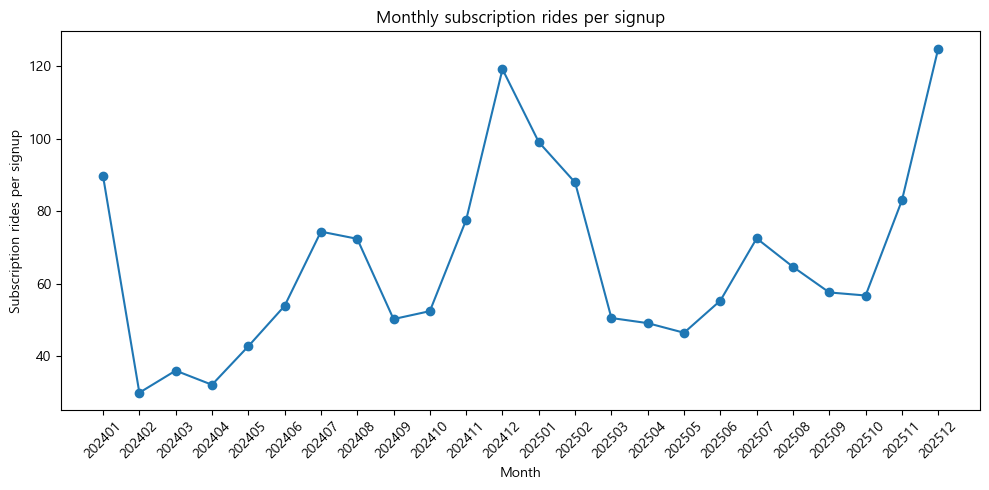

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_activation_df["month_ym"].astype(str), monthly_activation_df["activation_proxy"], marker="o")
plt.title("Monthly subscription rides per signup")
plt.xlabel("Month")
plt.ylabel("Subscription rides per signup")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "activation_01_monthly_sub_rides_per_signup.png", dpi=150)
plt.show()

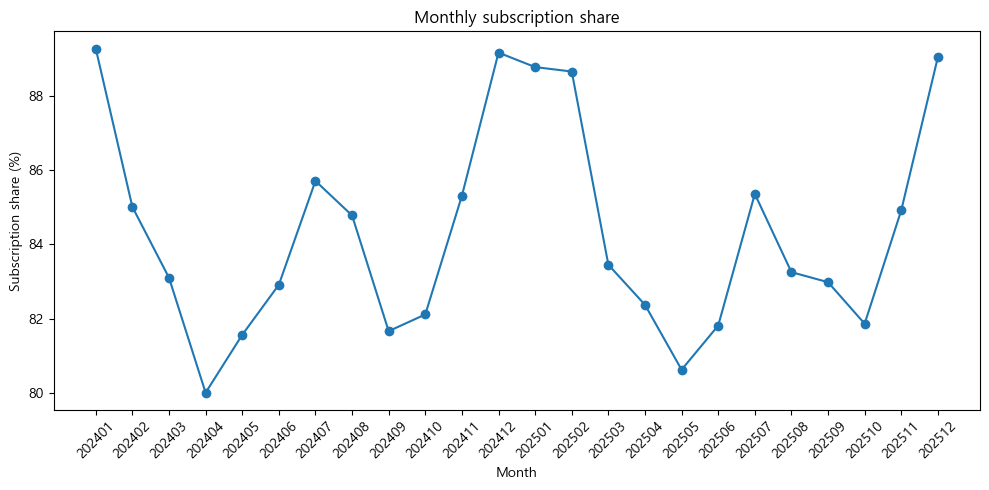

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_activation_df["month_ym"].astype(str), monthly_activation_df["same_month_subscription_share"] * 100, marker="o")
plt.title("Monthly subscription share")
plt.xlabel("Month")
plt.ylabel("Subscription share (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "activation_02_monthly_subscription_share.png", dpi=150)
plt.show()

## 4. 세그먼트별 Activation 강도

세그먼트 분석에서는 `age_band='기타'`를 제외합니다. 나이 미입력 집단은 특정 연령대 세그먼트로 해석할 수 없기 때문입니다.

In [24]:
segment_activation_df = pd.read_sql_query("""
WITH segment AS (
    SELECT gender, age_band,
           SUM(signup_cnt) AS signup_cnt,
           SUM(sub_ride_cnt) AS sub_ride_cnt,
           SUM(total_ride_cnt) AS total_ride_cnt
    FROM mart_growth_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY gender, age_band
),
total AS (
    SELECT SUM(signup_cnt) AS total_signup_cnt,
           SUM(sub_ride_cnt) AS total_sub_ride_cnt
    FROM segment
)
SELECT RANK() OVER (ORDER BY 1.0 * s.sub_ride_cnt / NULLIF(s.signup_cnt, 0) DESC) AS activation_rank,
       s.gender, s.age_band, s.signup_cnt, s.sub_ride_cnt, s.total_ride_cnt,
       ROUND(CASE WHEN s.signup_cnt > 0 THEN 1.0 * s.sub_ride_cnt / s.signup_cnt ELSE NULL END, 4) AS activation_proxy,
       ROUND(CASE WHEN s.total_ride_cnt > 0 THEN 1.0 * s.sub_ride_cnt / s.total_ride_cnt ELSE NULL END, 4) AS same_segment_subscription_share,
       ROUND(1.0 * s.signup_cnt / t.total_signup_cnt, 4) AS signup_share,
       ROUND(1.0 * s.sub_ride_cnt / t.total_sub_ride_cnt, 4) AS sub_ride_share,
       ROUND(1.0 * s.sub_ride_cnt / t.total_sub_ride_cnt - 1.0 * s.signup_cnt / t.total_signup_cnt, 4) AS sub_vs_signup_share_gap
FROM segment s
CROSS JOIN total t
ORDER BY activation_proxy DESC
""", conn)
segment_activation_df

,activation_rank,gender,age_band,signup_cnt,sub_ride_cnt,total_ride_cnt,activation_proxy,same_segment_subscription_share,signup_share,sub_ride_share,sub_vs_signup_share_gap
0,1,M,60대,20231,1906035,1993772,94.2136,0.9560,0.0231,0.0408,0.0177
1,2,M,70대이상,3855,360798,373262,93.5922,0.9666,0.0044,0.0077,0.0033
2,3,M,50대,51258,4518594,4815251,88.1539,0.9384,0.0585,0.0967,0.0382
3,4,M,30대,97687,8257169,9595274,84.5268,0.8605,0.1115,0.1767,0.0652
4,5,M,40대,80755,6030368,6673342,74.6749,0.9037,0.0922,0.1290,0.0369
5,6,F,50대,33887,2195966,2382960,64.8026,0.9215,0.0387,0.0470,0.0083
6,7,F,30대,76817,4708964,5654116,61.3011,0.8328,0.0877,0.1008,0.0131
7,8,F,60대,9769,572595,605946,58.6135,0.9450,0.0111,0.0123,0.0011
8,9,F,70대이상,1699,87692,95982,51.6139,0.9136,0.0019,0.0019,-0.0001
9,10,F,40대,61250,3008570,3470425,49.1195,0.8669,0.0699,0.0644,-0.0055


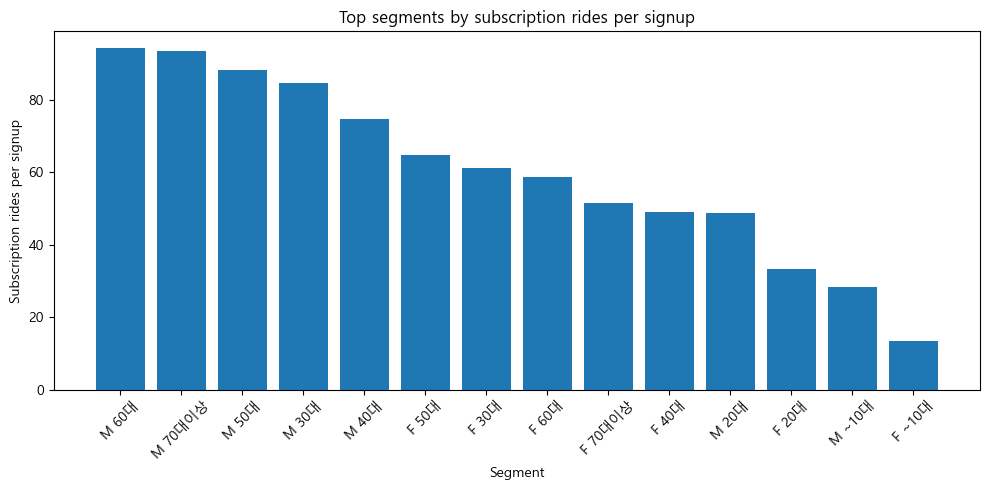

In [25]:
top_activation_df = segment_activation_df.copy()
top_activation_df["segment"] = top_activation_df["gender"].astype(str) + " " + top_activation_df["age_band"].astype(str)
plt.figure(figsize=(10, 5))
plt.bar(top_activation_df["segment"], top_activation_df["activation_proxy"])
plt.title("Top segments by subscription rides per signup")
plt.xlabel("Segment")
plt.ylabel("Subscription rides per signup")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "activation_03_top_segments_sub_rides_per_signup.png", dpi=150)
plt.show()

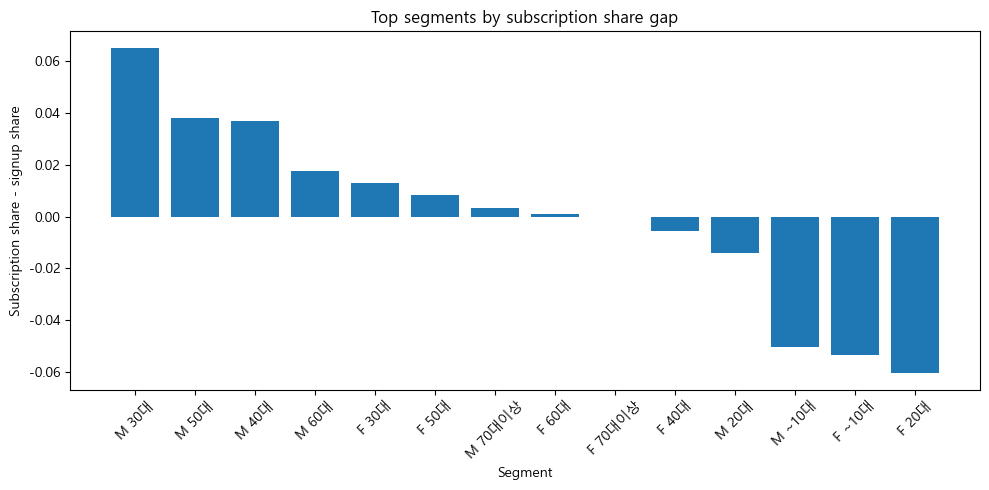

In [26]:
top_share_gap_df = segment_activation_df.sort_values("sub_vs_signup_share_gap", ascending=False).copy()
top_share_gap_df["segment"] = top_share_gap_df["gender"].astype(str) + " " + top_share_gap_df["age_band"].astype(str)
plt.figure(figsize=(10, 5))
plt.bar(top_share_gap_df["segment"], top_share_gap_df["sub_vs_signup_share_gap"])
plt.title("Top segments by subscription share gap")
plt.xlabel("Segment")
plt.ylabel("Subscription share - signup share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "activation_04_top_segments_share_gap.png", dpi=150)
plt.show()

## 5. 세그먼트별 Activation 유형 분류

In [27]:
activation_type_df = pd.read_sql_query("""
WITH segment AS (
    SELECT gender, age_band,
           SUM(signup_cnt) AS signup_cnt,
           SUM(sub_ride_cnt) AS sub_ride_cnt,
           SUM(total_ride_cnt) AS total_ride_cnt,
           CASE WHEN SUM(signup_cnt) > 0 THEN 1.0 * SUM(sub_ride_cnt) / SUM(signup_cnt) ELSE NULL END AS activation_proxy,
           CASE WHEN SUM(total_ride_cnt) > 0 THEN 1.0 * SUM(sub_ride_cnt) / SUM(total_ride_cnt) ELSE NULL END AS same_segment_subscription_share
    FROM mart_growth_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY gender, age_band
),
total AS (
    SELECT SUM(signup_cnt) AS total_signup_cnt,
           SUM(sub_ride_cnt) AS total_sub_ride_cnt
    FROM segment
),
base AS (
    SELECT s.*,
           1.0 * s.signup_cnt / t.total_signup_cnt AS signup_share,
           1.0 * s.sub_ride_cnt / t.total_sub_ride_cnt AS sub_ride_share,
           1.0 * s.sub_ride_cnt / t.total_sub_ride_cnt - 1.0 * s.signup_cnt / t.total_signup_cnt AS sub_vs_signup_share_gap
    FROM segment s
    CROSS JOIN total t
),
ranked AS (
    SELECT *,
           NTILE(3) OVER (ORDER BY signup_cnt) AS signup_tertile,
           NTILE(3) OVER (ORDER BY activation_proxy) AS activation_tertile
    FROM base
)
SELECT gender, age_band, signup_cnt, sub_ride_cnt, total_ride_cnt,
       ROUND(activation_proxy, 4) AS activation_proxy,
       ROUND(same_segment_subscription_share, 4) AS same_segment_subscription_share,
       ROUND(signup_share, 4) AS signup_share,
       ROUND(sub_ride_share, 4) AS sub_ride_share,
       ROUND(sub_vs_signup_share_gap, 4) AS sub_vs_signup_share_gap,
       signup_tertile, activation_tertile,
       CASE
            WHEN signup_tertile = 3 AND activation_tertile = 3 AND sub_vs_signup_share_gap > 0 THEN '가입 규모 큼 + 정기권 이용 강함'
            WHEN signup_tertile = 3 AND (activation_tertile <= 2 OR sub_vs_signup_share_gap < 0) THEN '가입은 많지만 정기권 이용 약함'
            WHEN signup_tertile <= 2 AND activation_tertile = 3 THEN '가입 규모는 작지만 이용 강도 높음'
            WHEN signup_tertile = 1 AND activation_tertile = 1 THEN '가입 규모 작음 + 이용 강도 낮음'
            WHEN same_segment_subscription_share >= 0.9 THEN '정기권 중심 이용 성향 강함'
            ELSE '일반'
       END AS activation_segment_type
FROM ranked
ORDER BY
    CASE
        WHEN signup_tertile = 3 AND activation_tertile = 3 AND sub_vs_signup_share_gap > 0 THEN 1
        WHEN signup_tertile = 3 AND (activation_tertile <= 2 OR sub_vs_signup_share_gap < 0) THEN 2
        WHEN signup_tertile <= 2 AND activation_tertile = 3 THEN 3
        WHEN signup_tertile = 1 AND activation_tertile = 1 THEN 4
        WHEN same_segment_subscription_share >= 0.9 THEN 5
        ELSE 6
    END,
    activation_proxy DESC;
""", conn)
activation_type_df

,gender,age_band,signup_cnt,sub_ride_cnt,total_ride_cnt,activation_proxy,same_segment_subscription_share,signup_share,sub_ride_share,sub_vs_signup_share_gap,signup_tertile,activation_tertile,activation_segment_type
0,M,30대,97687,8257169,9595274,84.5268,0.8605,0.1115,0.1767,0.0652,3,3,가입 규모 큼 + 정기권 이용 강함
1,M,20대,141409,6887715,8927316,48.7078,0.7715,0.1614,0.1474,-0.0140,3,1,가입은 많지만 정기권 이용 약함
2,F,20대,141196,4702323,6347383,33.3035,0.7408,0.1611,0.1006,-0.0605,3,1,가입은 많지만 정기권 이용 약함
3,M,~10대,93721,2649824,3685290,28.2735,0.7190,0.1070,0.0567,-0.0503,3,1,가입은 많지만 정기권 이용 약함
4,M,60대,20231,1906035,1993772,94.2136,0.9560,0.0231,0.0408,0.0177,1,3,가입 규모는 작지만 이용 강도 높음
5,M,70대이상,3855,360798,373262,93.5922,0.9666,0.0044,0.0077,0.0033,1,3,가입 규모는 작지만 이용 강도 높음
6,M,50대,51258,4518594,4815251,88.1539,0.9384,0.0585,0.0967,0.0382,2,3,가입 규모는 작지만 이용 강도 높음
7,M,40대,80755,6030368,6673342,74.6749,0.9037,0.0922,0.1290,0.0369,2,2,정기권 중심 이용 성향 강함
8,F,50대,33887,2195966,2382960,64.8026,0.9215,0.0387,0.0470,0.0083,1,2,정기권 중심 이용 성향 강함
9,F,60대,9769,572595,605946,58.6135,0.9450,0.0111,0.0123,0.0011,1,2,정기권 중심 이용 성향 강함


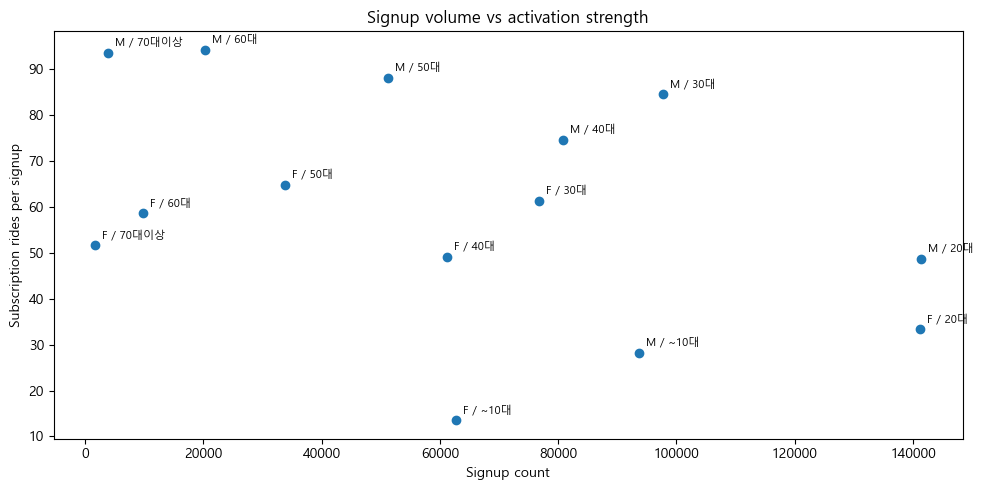

In [28]:
plt.figure(figsize=(10, 5))
plt.scatter(activation_type_df["signup_cnt"], activation_type_df["activation_proxy"])
for _, row in activation_type_df.iterrows():
    plt.annotate(
        f"{row['gender']} / {row['age_band']}",
        (row["signup_cnt"], row["activation_proxy"]),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left",
        fontsize=8,
    )
plt.title("Signup volume vs activation strength")
plt.xlabel("Signup count")
plt.ylabel("Subscription rides per signup")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "activation_05_signup_vs_activation_scatter.png", dpi=150)
plt.show()

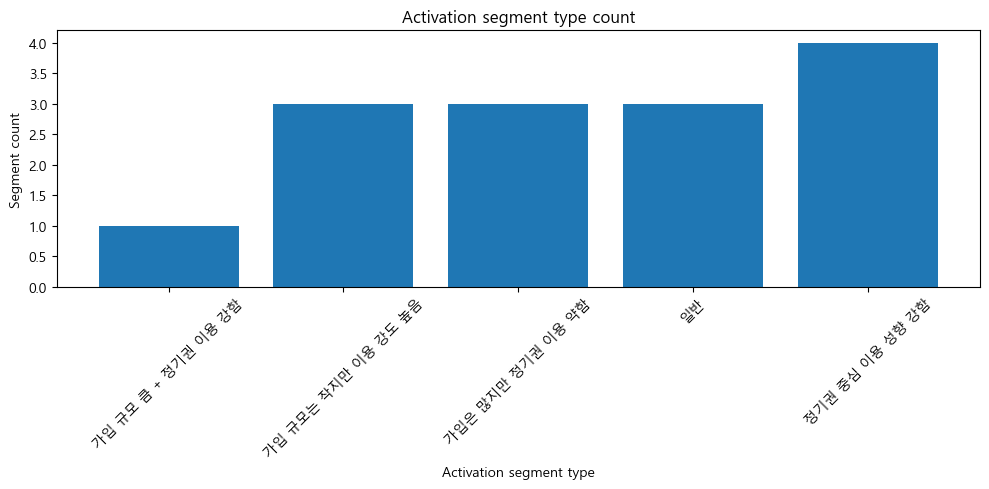

,activation_segment_type,segment_count
0,가입 규모 큼 + 정기권 이용 강함,1
1,가입 규모는 작지만 이용 강도 높음,3
2,가입은 많지만 정기권 이용 약함,3
3,일반,3
4,정기권 중심 이용 성향 강함,4


In [29]:
type_count_df = activation_type_df.groupby("activation_segment_type").size().reset_index(name="segment_count")
plt.figure(figsize=(10, 5))
plt.bar(type_count_df["activation_segment_type"], type_count_df["segment_count"])
plt.title("Activation segment type count")
plt.xlabel("Activation segment type")
plt.ylabel("Segment count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "activation_06_activation_type_count.png", dpi=150)
plt.show()
type_count_df

## 6. 월별 가입은 많지만 정기권 이용이 약한 구간

In [30]:
monthly_weak_activation_df = pd.read_sql_query("""
WITH ranked AS (
    SELECT month_ym, month_date, gender, age_band, signup_cnt, sub_ride_cnt, total_ride_cnt,
           CASE WHEN signup_cnt > 0 THEN 1.0 * sub_ride_cnt / signup_cnt ELSE NULL END AS sub_rides_per_signup,
           CASE WHEN total_ride_cnt > 0 THEN 1.0 * sub_ride_cnt / total_ride_cnt ELSE NULL END AS same_month_subscription_share,
           NTILE(4) OVER (PARTITION BY month_ym ORDER BY signup_cnt) AS signup_quartile_in_month,
           NTILE(4) OVER (PARTITION BY month_ym ORDER BY CASE WHEN signup_cnt > 0 THEN 1.0 * sub_ride_cnt / signup_cnt ELSE NULL END) AS activation_quartile_in_month
    FROM mart_growth_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
)
SELECT month_ym, gender, age_band, signup_cnt, sub_ride_cnt, total_ride_cnt,
       ROUND(sub_rides_per_signup, 4) AS sub_rides_per_signup,
       ROUND(same_month_subscription_share, 4) AS same_month_subscription_share,
       signup_quartile_in_month, activation_quartile_in_month
FROM ranked
WHERE signup_quartile_in_month = 4
  AND activation_quartile_in_month <= 2
ORDER BY month_ym, signup_cnt DESC
""", conn)
monthly_weak_activation_df

,month_ym,gender,age_band,signup_cnt,sub_ride_cnt,total_ride_cnt,sub_rides_per_signup,same_month_subscription_share,signup_quartile_in_month,activation_quartile_in_month
0,202401,M,20대,2302,180470,218358,78.3970,0.8265,4,2
1,202401,F,20대,1896,115654,138023,60.9989,0.8379,4,1
2,202402,M,50대,4642,116901,123488,25.1833,0.9467,4,2
3,202403,F,20대,8724,193747,264300,22.2085,0.7331,4,1
4,202403,M,20대,8504,270995,354380,31.8668,0.7647,4,2
5,202404,F,20대,15360,294605,426678,19.1800,0.6905,4,1
6,202404,M,20대,13299,369704,505081,27.7994,0.7320,4,2
7,202405,F,20대,11498,305391,422243,26.5604,0.7233,4,1
8,202405,M,20대,10531,390207,519473,37.0532,0.7512,4,1
9,202406,M,20대,9168,409661,536211,44.6838,0.7640,4,2


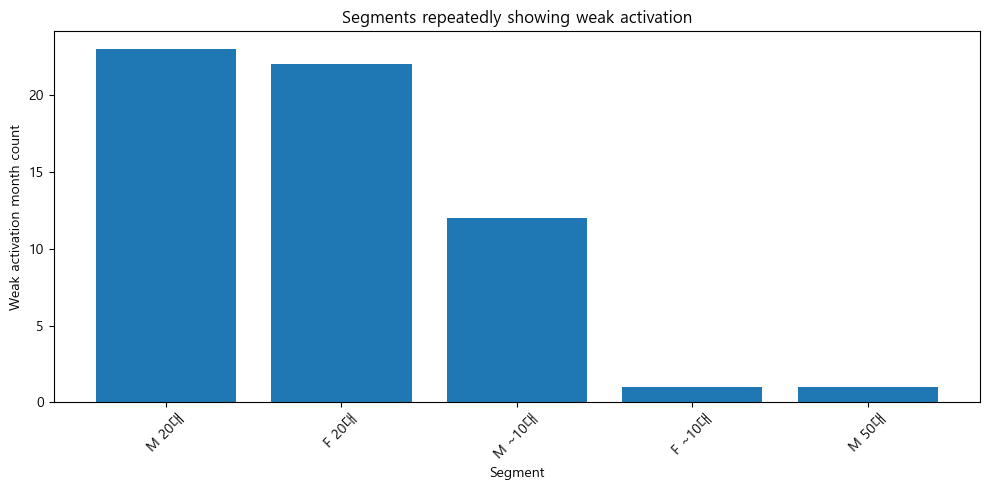

,gender,age_band,weak_month_count
2,M,20대,23
0,F,20대,22
4,M,~10대,12
1,F,~10대,1
3,M,50대,1


In [31]:
weak_count_df = monthly_weak_activation_df.groupby(["gender", "age_band"]).size().reset_index(name="weak_month_count")
weak_count_df = weak_count_df.sort_values("weak_month_count", ascending=False)
weak_count_top_df = weak_count_df.head(10).copy()
weak_count_top_df["segment"] = weak_count_top_df["gender"].astype(str) + " " + weak_count_top_df["age_band"].astype(str)
plt.figure(figsize=(10, 5))
plt.bar(weak_count_top_df["segment"], weak_count_top_df["weak_month_count"])
plt.title("Segments repeatedly showing weak activation")
plt.xlabel("Segment")
plt.ylabel("Weak activation month count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "activation_07_repeated_weak_activation_segments.png", dpi=150)
plt.show()
weak_count_df

## 7. 분석 요약 저장

In [32]:
def df_to_md(df):
    if df is None or df.empty:
        return "_결과 없음_"
    temp = df.copy().fillna("").astype(str)
    def clean(x):
        return str(x).replace("\n", "<br>").replace("|", "\\|")
    header = "| " + " | ".join(clean(c) for c in temp.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(temp.columns)) + " |"
    rows = ["| " + " | ".join(clean(v) for v in row) + " |" for row in temp.values.tolist()]
    return "\n".join([header, sep] + rows)

summary_md = f"""# Activation 분석 결과 요약

## 1. 월별 Activation 흐름

{df_to_md(monthly_activation_df)}

## 2. 세그먼트별 Activation 강도 TOP 10

{df_to_md(segment_activation_df.head(10))}

## 3. 가입 비중 대비 정기권 이용 비중이 높은 세그먼트 TOP 10

{df_to_md(top_share_gap_df)}

## 4. 세그먼트 유형 분류

{df_to_md(activation_type_df)}

## 5. 월별 가입은 많지만 정기권 이용이 약한 구간

{df_to_md(monthly_weak_activation_df)}

## 6. 반복적으로 약한 Activation을 보인 세그먼트

{df_to_md(weak_count_df)}

## 해석 메모

- `sub_rides_per_signup`은 정기권 이용건수 / 신규가입자 수로 계산한 Activation proxy이다.
- 이 값은 개인 단위 전환율이 아니라 월 × 성별 × 연령대 수준의 대체지표이다.
- 월별 전체 흐름은 `age_band='기타'`를 포함하여 전체 가입 규모 기준으로 본다.
- 성별·연령대 세그먼트 해석에서는 `age_band='기타'`를 제외한다.
- `sub_vs_signup_share_gap`가 양수이면 가입 비중보다 정기권 이용 비중이 더 큰 세그먼트이다.
- `가입은 많지만 정기권 이용 약함` 유형은 온보딩 또는 정기권 이용 유도 개선 후보로 해석할 수 있다.
"""

summary_path = REPORT_DIR / "activation_analysis_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")
print("요약 저장:", summary_path)
print("이미지 저장 폴더:", IMAGE_DIR)


요약 저장: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\reports\activation_analysis_summary.md
이미지 저장 폴더: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\activation


In [33]:
conn.close()
print("SQLite 연결 종료 완료")

SQLite 연결 종료 완료
